# Incluir o no los grupos BERT en la expansión

Los 1.040 grupos BERT son nodos artificiales que unen sinónimos de enfermedad y no pueden ser
semilla de ningún gen, ya que ninguno tiene una sola arista `GDA`. Sin embargo sí pueden entrar por la expansión: un gen siembra sus enfermedades asociadas, DIAMOnD expande dentro del plano de enfermedades, y si los grupos están en ese plano puede pisar uno y seguir desde
ahí hacia sus miembros.

Este notebook compara las dos formas de correr la celda `gene_a_disease`:

| rama | plano de enfermedades | nodos | aristas |
|---|---|---|---|
| con BERT | MONDO más la estrella `DISEASE_BERT` | 12.368 | 16.433 |
| sin BERT | solo MONDO entre enfermedades reales | 5.318 | 7.836 |

Las dos usan las mismas 150 anclas con el mismo bin, así que es la misma consulta sobre dos redes. Como con los grupos los CUIs miembro vuelven al plano, cada gen gana semillas: la comparación es pareada por consulta, no por tamaño del conjunto semilla.

Lee los parquet que ya están en `resultados/` y `resultados_con_grupos/`; no corre DIAMOnD ni necesita Neo4j.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

#comparacion.py apila los parquet de una carpeta de resultados en dos tablas largas
import comparacion
#de graficos salen las primitivas de dibujo: asi la comparacion promedia y dibuja igual que los
#PDF por plano, y los numeros coinciden con resumen_celdas.csv
from graficos import COLOR_APAREADO, COLOR_REAL, COLOR_UNIFORME, _banda, banda_de_corridas, \
    curva_de_recall_media
#los nombres de los tres bins de tamano del conjunto semilla: bajo, medio y alto
from paso0 import BINS
#el unico nivel de remocion que tiene nulo: se esconde el 30% de las semillas
from recall import FRAC_CON_CONTROL

#comparacion importa graficos, que fija el backend Agg para escribir PDF: se vuelve al inline
%matplotlib inline

#la celda que corre en el plano de enfermedades, la unica afectada por los grupos
CELDA = "gene_a_disease"
#una rama por carpeta de resultados. El orden es el de las filas de las laminas
RAMAS = {"con BERT": "resultados_con_grupos", "sin BERT": "resultados"}

#un color por fuente, los mismos de gene.pdf y disease.pdf (paleta Okabe-Ito)
COLOR_POR_FUENTE = {"real": COLOR_REAL, "apareado": COLOR_APAREADO, "uniforme": COLOR_UNIFORME}
#como se nombra cada fuente en las leyendas
ETIQUETA = {"real": "real", "apareado": "nulo apareado por grado", "uniforme": "nulo uniforme"}

#{rama: (trazas, recalls)}, ya con las corridas truncadas arrastradas y los folds ausentes puestos
datos = comparacion.cargar(RAMAS, CELDA)
#los ids de los 1.040 grupos, para reconocerlos entre los nodos que DIAMOnD agrega
grupos = comparacion.ids_de_grupos_bert()

#control: las dos ramas tienen que traer las mismas 150 anclas, y el recall una fuente menos que
#la LCC, porque los folds del nulo se corren solo sobre los conjuntos apareados
for rama, (trazas, recalls) in datos.items():
    print(f"{rama}: {trazas.ancla.nunique()} anclas, "
          f"fuentes en LCC {sorted(trazas.fuente.unique())}, "
          f"en recall {sorted(recalls.fuente.unique())}")


/home/ezequel/tesis/.venv-optimuskg/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


con BERT: 150 anclas, fuentes en LCC ['apareado', 'real', 'uniforme'], en recall ['apareado', 'real']
sin BERT: 150 anclas, fuentes en LCC ['apareado', 'real', 'uniforme'], en recall ['apareado', 'real']


## Semillas en la componente mayor del módulo

La fracción de las semillas del gen que están en la componente conexa mayor del módulo, iteración
a iteración: la ley de crecimiento. Va la fracción y no el conteo porque con los grupos cada gen
tiene más semillas por construcción, y el conteo arrancaría más alto sin que eso signifique nada.

Cada panel tiene la corrida real y sus dos nulos, así que se lee igual que `disease.pdf`. Las
bandas son un desvío entre corridas: para el nulo resume sus 20 sorteos, para la real la
dispersión entre las anclas del bin.

In [2]:
#la fraccion y no el conteo: con grupos cada gen tiene mas semillas por construccion, asi que el
#conteo de esa rama arrancaria mas alto sin que eso signifique nada
COLUMNA_LCC = "frac_semillas_lcc"
#las tres series de cada panel: la corrida real y sus dos nulos
FUENTES_LCC = ("real", "apareado", "uniforme")


def rango_de_vecinos(trazas_del_bin):
    """cuantos vecinos de la capa B tienen las anclas del bin."""
    #se lee de la corrida real y no de casos.csv, que en una comparacion pareada trae los de la
    #otra rama: las anclas son las mismas, pero la cantidad de semillas no
    real = trazas_del_bin[trazas_del_bin["fuente"] == "real"]
    #n_semillas se repite en las 101 filas de cada corrida, alcanza con la primera de cada ancla
    por_ancla = real.groupby("ancla")["n_semillas"].first()
    return f"{por_ancla.min():.0f} a {por_ancla.max():.0f} vecinos"


def rotulo_del_bin(nombre_bin):
    """El rango de vecinos que define al bin, contado en la rama sin BERT."""
    #los bins se armaron partiendo en tercios las semillas del plano sin BERT, asi que ese es el
    #unico rango que describe al bin. En la rama con BERT los mismos genes tienen mas semillas
    trazas = datos["sin BERT"][0]
    del_bin = trazas[trazas["bin"] == nombre_bin]
    return f"{rango_de_vecinos(del_bin)}, {del_bin.ancla.nunique()} genes"


def _curvas_lcc(trazas, bins):
    """{bin: {"curvas": {fuente: (media, desvio)}}} de una rama."""
    salida = {}
    for nombre_bin in bins:
        #las anclas de este bin
        del_bin = trazas[trazas["bin"] == nombre_bin]
        salida[nombre_bin] = {
            #banda_de_corridas da (media, desvio) por iteracion entre las corridas del conjunto:
            #para un nulo resume sus 20 sorteos, para la real la dispersion entre anclas
            "curvas": {fuente: banda_de_corridas(del_bin[del_bin["fuente"] == fuente], COLUMNA_LCC)
                       for fuente in FUENTES_LCC}}
    return salida


def LCC_graficar_con_bert(bins=BINS):
    """Arma lo necesario para graficar la LCC de la rama con los grupos BERT en el plano."""
    #datos[rama] es el par (trazas, recalls); la LCC sale de las trazas
    return _curvas_lcc(datos["con BERT"][0], bins)


def LCC_graficar_sin_bert(bins=BINS):
    """Lo mismo para la rama sin los grupos. Mismas anclas y mismos bins que la anterior."""
    return _curvas_lcc(datos["sin BERT"][0], bins)


def juntar_todo_lcc(bins=BINS):
    """Junta las dos ramas: una fila por rama y una columna por bin"""
    #cada rama arma sus curvas por separado y recien aca se ponen en la misma grilla
    por_rama = {"con BERT": LCC_graficar_con_bert(bins), "sin BERT": LCC_graficar_sin_bert(bins)}
    fig, ejes = plt.subplots(len(por_rama), len(bins), figsize=(5 * len(bins), 4 * len(por_rama)),
                             squeeze=False, sharex=True, sharey=True)
    for fila, (rama, del_rama) in enumerate(por_rama.items()):
        for columna, nombre_bin in enumerate(bins):
            eje = ejes[fila][columna]
            for fuente, (media, desvio) in del_rama[nombre_bin]["curvas"].items():
                color = COLOR_POR_FUENTE[fuente]
                #la media va como linea llena y la dispersion como banda tenue alrededor
                eje.plot(media.index, media, color=color, label=ETIQUETA[fuente])
                _banda(eje, media, desvio, color, None, clip=(0, 1))
            eje.set_ylim(0, 1)
            eje.set_title(f"{rama} — bin {nombre_bin}\n{rotulo_del_bin(nombre_bin)}",
                          fontsize=10)
            #el eje x se rotula solo abajo de todo, las filas comparten escala
            if fila == len(por_rama) - 1:
                eje.set_xlabel("iteración")
        ejes[fila][0].set_ylabel("frac. de semillas en la LCC")
    ejes[0][0].legend(fontsize=8)
    fig.suptitle(f"{CELDA}: semillas en la componente mayor, con y sin los grupos BERT")
    fig.tight_layout()
    return fig


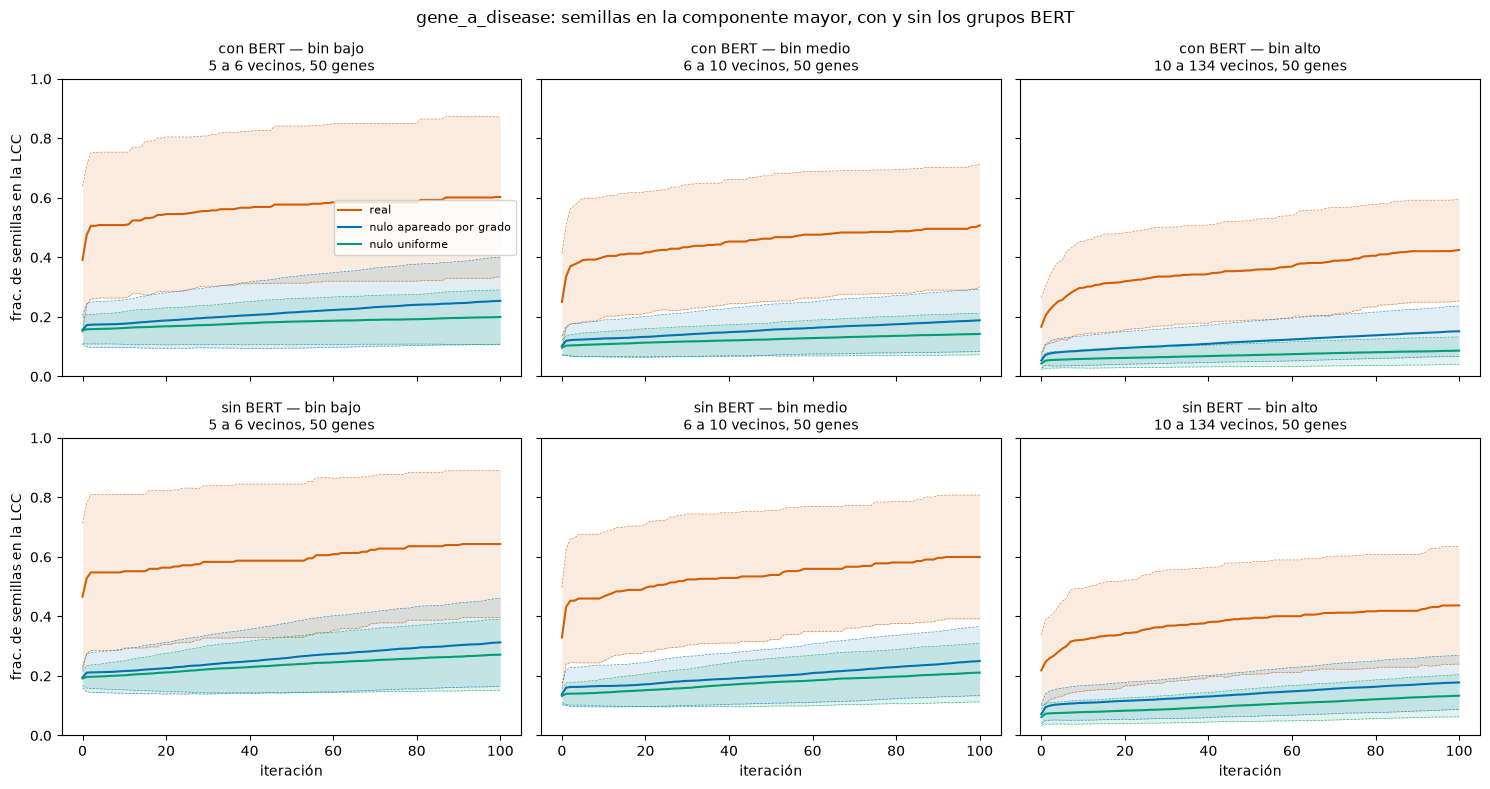

In [3]:
#la lamina de la LCC: arriba la rama con los grupos, abajo la rama sin ellos
fig = juntar_todo_lcc()


## Recall de las semillas escondidas

Se esconde el 30 % de las semillas, se corre DIAMOnD con las visibles y se mide qué fracción de
las escondidas aparece entre los primeros *rank* nodos agregados.

Acá hay **dos** series y no tres: `runner.py` corre los folds de recall solo sobre los conjuntos
apareados, así que el nulo uniforme no existe para esta métrica. La banda es el IC95 entre anclas,
que es la dispersión que corresponde a una media de medias.

In [4]:
FUENTES_RECALL = ("real", "apareado")


def _curvas_recall(recalls, bins):
    """{bin: {fuente: (media, ic95)}} de una rama, en el nivel de remocion que tiene nulo."""
    salida = {}
    for nombre_bin in bins:
        #se filtra al 30% escondido
        del_bin = recalls[(recalls["bin"] == nombre_bin)
                          & (recalls["frac_escondida"] == FRAC_CON_CONTROL)]
        #curva_de_recall_media promedia primero los folds de cada ancla y recien despues entre
        #anclas: los folds de un ancla esconden semillas del mismo conjunto y no son
        #observaciones independientes. Devuelve (media, semiancho del IC95 entre anclas)
        salida[nombre_bin] = {
            fuente: curva_de_recall_media(del_bin[del_bin["fuente"] == fuente])
            for fuente in FUENTES_RECALL}
    return salida




def juntar_todo_recall(bins=BINS):
    """Junta las dos ramas en una lamina: una fila por rama, una columna por bin."""
    recall_graficar_con_bert = _curvas_recall(datos["con BERT"][1], bins)
    recall_graficar_sin_bert = _curvas_recall(datos["sin BERT"][1], bins)
    por_rama = {"con BERT": recall_graficar_con_bert,
                "sin BERT": recall_graficar_sin_bert}
    fig, ejes = plt.subplots(len(por_rama), len(bins), figsize=(5 * len(bins), 4 * len(por_rama)),
                             squeeze=False, sharex=True, sharey=True)
    for fila, (rama, del_rama) in enumerate(por_rama.items()):
        for columna, nombre_bin in enumerate(bins):
            eje = ejes[fila][columna]
            for fuente, (media, ic95) in del_rama[nombre_bin].items():
                color = COLOR_POR_FUENTE[fuente]
                #aca la banda es el IC95 de la media entre anclas, no la dispersion entre corridas
                eje.plot(media.index, media, color=color, label=ETIQUETA[fuente])
                _banda(eje, media, ic95, color, None, clip=(0, 1))
            eje.set_ylim(0, 1)
            eje.set_title(f"{rama} — bin {nombre_bin}", fontsize=10)
            if fila == len(por_rama) - 1:
                #el eje x es el rank y no la iteracion: cuantos nodos lleva agregados DIAMOnD
                eje.set_xlabel("rank (nodos agregados)")
        ejes[fila][0].set_ylabel("recall de semillas escondidas")
    ejes[0][0].legend(fontsize=8)
    fig.suptitle(f"{CELDA}: recall de las semillas escondidas, con y sin los grupos BERT")
    fig.tight_layout()
    return fig


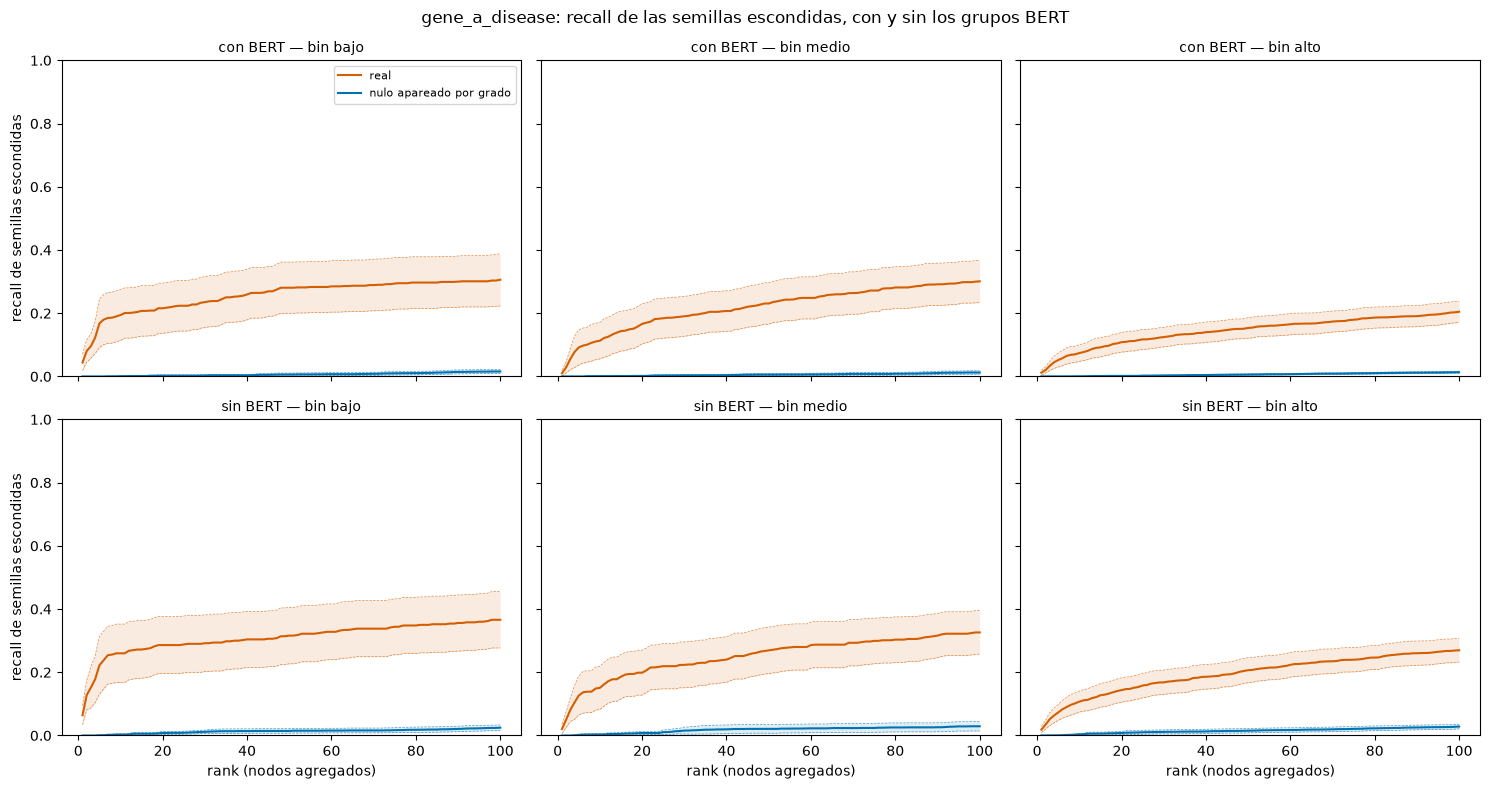

In [5]:
#la misma grilla para el recall, con una serie menos por panel
fig = juntar_todo_recall()


## Las dos ramas superpuestas

Las mismas curvas de arriba, pero encimadas en vez de una fila por rama: arriba la LCC, abajo el
recall, una columna por bin. Acá el color distingue la rama y no la fuente, al revés que en las
láminas anteriores y que en los PDF por plano.

No reprocesa nada: llama a las mismas cuatro funciones por rama y solo cambia la grilla. Con
`con_nulo=False` quedan solo las curvas reales, y con `con_banda=False` se van las bandas, que en
la fila de la LCC son anchas y se tapan entre sí.

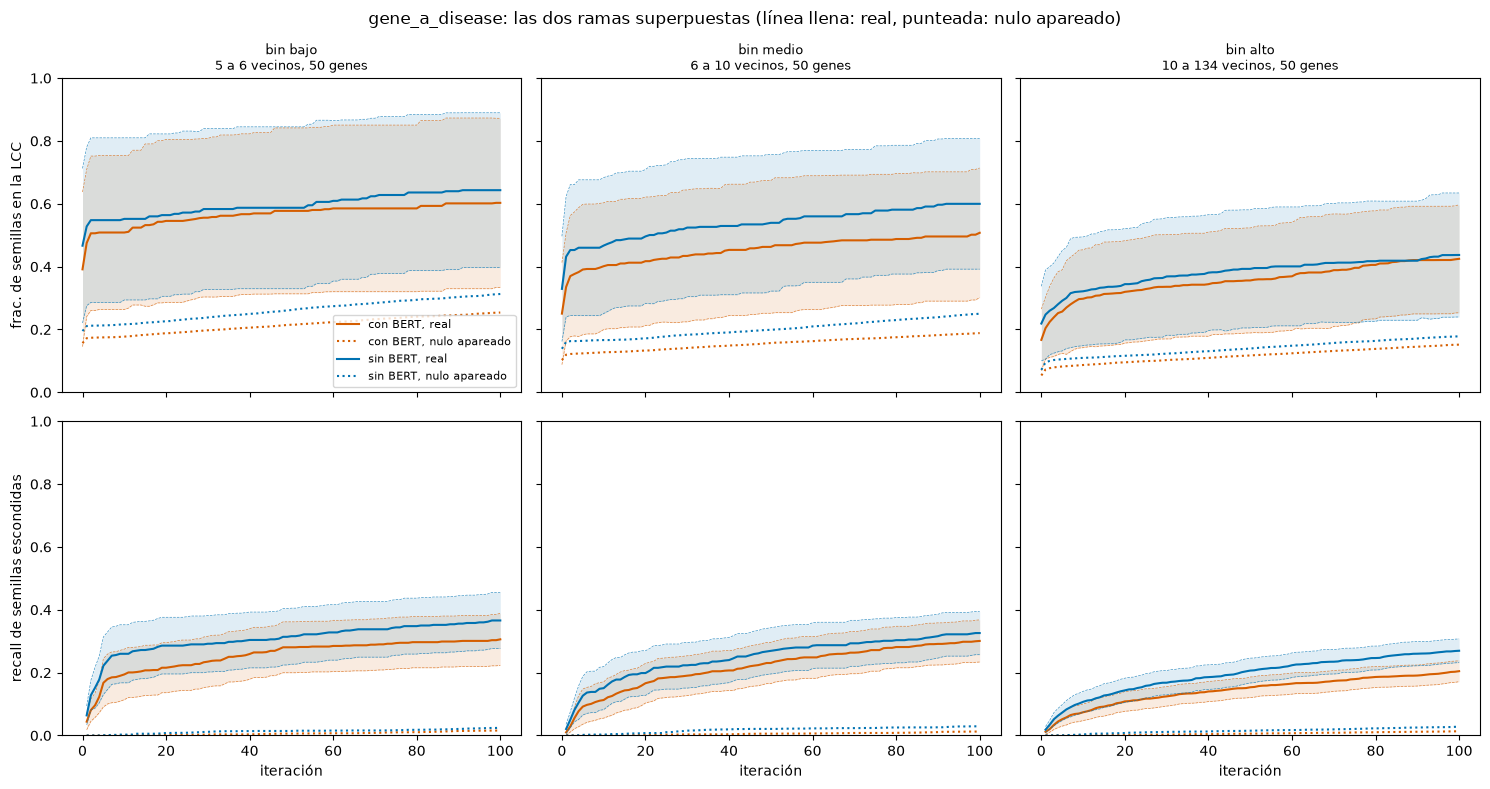

In [6]:
#en esta lamina el color es la rama, no la fuente: son las mismas dos de la version anterior
#del notebook, para que se reconozcan
COLOR_POR_RAMA = {"con BERT": "#D55E00", "sin BERT": "#0072B2"}


def juntar_todo(bins=BINS, con_nulo=True, con_banda=True):
    """Las dos metricas en una lamina con las ramas superpuestas: LCC arriba, recall abajo.

    No recalcula nada: usa las mismas cuatro funciones por rama y solo cambia como se reparten
    los paneles. Del nulo se dibuja solo el apareado y sin banda, porque lo que se compara aca
    son las ramas y seis curvas con banda en un panel no se leen. El uniforme queda en las
    laminas por rama, que son las que tienen las tres fuentes.
    """
    #se llama a _curvas_lcc y _curvas_recall directamente, que son las que arman los datos en
    #las dos secciones anteriores, sin pasar por los envoltorios por rama
    lcc = {rama: _curvas_lcc(datos[rama][0], bins) for rama in COLOR_POR_RAMA}
    rec = {rama: _curvas_recall(datos[rama][1], bins) for rama in COLOR_POR_RAMA}
    #sharey por fila: las dos metricas son fracciones pero viven en rangos distintos
    fig, ejes = plt.subplots(2, len(bins), figsize=(5 * len(bins), 8), squeeze=False,
                             sharex=True, sharey="row")
    for columna, nombre_bin in enumerate(bins):
        arriba, abajo = ejes[0][columna], ejes[1][columna]
        #el rango que define al bin, uno solo para las dos ramas
        rotulos = [f"bin {nombre_bin}", rotulo_del_bin(nombre_bin)]
        for rama in lcc:
            color = COLOR_POR_RAMA[rama]
            #arriba, la fraccion de semillas en la LCC: banda de un desvio entre corridas
            media, desvio = lcc[rama][nombre_bin]["curvas"]["real"]
            arriba.plot(media.index, media, color=color, label=f"{rama}, real")
            if con_banda:
                _banda(arriba, media, desvio, color, None, clip=(0, 1))
            #abajo, el recall: la banda es el IC95 de la media entre anclas
            media, ic95 = rec[rama][nombre_bin]["real"]
            abajo.plot(media.index, media, color=color, label=f"{rama}, real")
            if con_banda:
                _banda(abajo, media, ic95, color, None, clip=(0, 1))
            if con_nulo:
                #el nulo apareado va punteado y sin banda, como referencia de piso
                nulo, _ = lcc[rama][nombre_bin]["curvas"]["apareado"]
                arriba.plot(nulo.index, nulo, ":", color=color, label=f"{rama}, nulo apareado")
                nulo, _ = rec[rama][nombre_bin]["apareado"]
                abajo.plot(nulo.index, nulo, ":", color=color)
        arriba.set_title("\n".join(rotulos), fontsize=9)
        arriba.set_ylim(0, 1)
        #las dos metricas son fracciones y se muestran en su rango completo
        abajo.set_ylim(0, 1)
        abajo.set_xlabel("iteración")
    ejes[0][0].set_ylabel("frac. de semillas en la LCC")
    ejes[1][0].set_ylabel("recall de semillas escondidas")
    ejes[0][0].legend(fontsize=8)
    fig.suptitle(f"{CELDA}: las dos ramas superpuestas "
                 f"(línea llena: real, punteada: nulo apareado)")
    fig.tight_layout()
    return fig


fig = juntar_todo()


## ¿DIAMOnD usa los grupos al expandir?

Es la pregunta de fondo: si los grupos están en el plano, ¿los toma, y cuándo? Para cada corrida
de la rama con BERT, qué fracción de los nodos agregados son grupos, en las primeras 10
iteraciones y en las 100. La referencia es su peso en el plano, 1.040 de 12.368 nodos, el 8,4 %.
Los dos nulos sirven de contraste: ninguno puede tener grupos como semilla, así que cualquier
diferencia es de la expansión.

In [7]:
#solo la rama con BERT: en la otra los grupos no estan en el plano y no hay nada que contar
con_bert = datos["con BERT"][0]
#la iteracion 0 es el estado inicial y no agrega ningun nodo; las filas arrastradas tampoco
#describen uno (se agregan para completar las corridas que se cortaron antes del presupuesto)
agregados = con_bert[(con_bert["iteracion"] >= 1) & (~con_bert["arrastrada"])].copy()
#marca cada nodo agregado segun sea un grupo BERT o una enfermedad concreta
agregados["es_grupo"] = agregados["nodo"].isin(grupos)

filas = []
#una fila por bin y fuente: la real y sus dos nulos, que sirven de contraste
for (nombre_bin, fuente), del_grupo in agregados.groupby(["bin", "fuente"]):
    #las primeras 10 iteraciones son los nodos que DIAMOnD eligio primero, los de rank mas alto
    primeras = del_grupo[del_grupo["iteracion"] <= 10]
    filas.append({"bin": nombre_bin, "fuente": ETIQUETA[fuente],
                  "grupos en iteraciones 1 a 10 %": round(100 * primeras.es_grupo.mean(), 1),
                  "grupos en iteraciones 1 a 100 %": round(100 * del_grupo.es_grupo.mean(), 1)})

#la referencia para leer la tabla es el peso de los grupos en el plano: 1.040 de 12.368 nodos
pd.DataFrame(filas).set_index(["bin", "fuente"]).loc[list(BINS)]


grupos en iteraciones 1 a 10 %  \
bin   fuente                                                    
bajo  nulo apareado por grado                             4.2   
      real                                                8.6   
      nulo uniforme                                      10.3   
medio nulo apareado por grado                             3.7   
      real                                               12.4   
      nulo uniforme                                       9.2   
alto  nulo apareado por grado                             4.5   
      real                                               17.4   
      nulo uniforme                                       9.2   

                               grupos en iteraciones 1 a 100 %  
bin   fuente                                                    
bajo  nulo apareado por grado                              6.7  
      real                                                 6.3  
      nulo uniforme                                        6.8  
medio nulo apareado por grado                              6.4  
      real                                                 6.1  
      nulo uniforme                                        7.0  
alto  nulo apareado por grado                              6.3  
      real                                                 7.8  
      nulo uniforme                                        7.1

## Lectura

### Cómo se calculan las métricas

**Fracción de semillas en la LCC.** En cada iteración el módulo son las semillas más los nodos que DIAMOnD ya agregó. De ese módulo se toma la componente conexa que más semillas contiene, y la métrica es cuántas semillas tiene esa componente dividido el total de semillas del ancla. Los grupos BERT pueden entrar en la componente y agrandarla, pero nunca cuentan como semilla porque no tienen ninguna asociación con genes. La curva es el promedio entre corridas, donde una corrida es un par de ancla y sorteo. La real tiene un solo sorteo por ancla, así que promedia las anclas del bin, y cada nulo promedia sus 20 sorteos sobre esas mismas anclas. La banda es un desvío estándar entre corridas.

**Recall.** Se esconde el 30 % de las semillas del ancla, se corre DIAMOnD con las visibles, y el recall en el rank r es la fracción de las escondidas que aparece entre los primeros r nodos agregados. Hay 5 folds por ancla, cada uno con otro sorteo de escondidas, y el nulo repite esos mismos folds sobre 5 de los conjuntos apareados. La curva promedia primero los folds dentro de cada ancla y recién después entre anclas, porque los folds de un ancla esconden semillas del mismo conjunto y no son observaciones independientes. La banda es el IC95 entre anclas. Un grupo BERT nunca puede ser un acierto, porque para ser acierto tendría que haber sido semilla.

**Bins.** Se arman una sola vez, contando las semillas de cada gen en el plano sin BERT. Los genes con al menos 5 semillas se ordenan de menos a más, se parten en tres tercios del mismo tamaño y se sortean 50 genes por tercio. La rama con BERT usa esos mismos 150 genes con esos mismos bins, pero ahí cada gen tiene más semillas, porque vuelven al plano los CUIs que solo se conectan con la taxonomía a través de un grupo. Por eso los rangos de vecinos de los títulos son los de la rama sin BERT, que es la que define los bins. En la rama con BERT el bin bajo va de 5 a 15 semillas, el medio de 7 a 20 y el alto de 12 a 163.

### Qué muestran

**Con grupos, cada ancla gana semillas.** Las medianas pasan de 5 a 6, de 7,5 a 10 y de 18,5 a 25,5
en los tres bins, y las 50 anclas del bin alto ganan alguna. Con los bordes del primer batch, 46
anclas (23 del bin bajo y 23 del medio) quedarían en otro bin: la comparación es pareada por consulta,
no por tamaño de conjunto semilla.

**En números absolutos todo baja un poco, pero la distancia al nulo se mantiene.** La fracción final de
semillas en la componente mayor pasa de 0,64 a 0,60, de 0,60 a 0,51 y de 0,44 a 0,43; el recall final
de 0,37 a 0,31, de 0,33 a 0,30 y de 0,27 a 0,21. El nulo apareado también baja (recall de 0,025 a
0,016, de 0,029 a 0,012 y de 0,028 a 0,013), así que en las dos versiones y en los tres bins la
corrida real queda muy por encima de su nulo.

**El temor de que los grupos inflen el recall no se confirma: el recall baja en vez de subir.** Solo
entre el 7,5 % y el 8,5 % de las semillas escondidas tiene una hermana de grupo entre las visibles,
así que la recuperación de casi sinónimos a través del grupo tiene poco margen. Lo que sí se ve es que
DIAMOnD toma grupos temprano: son el 8,6 %, 12,4 % y 17,4 % de los primeros 10 nodos agregados en la
corrida real, contra 3,7 % a 4,5 % en el nulo apareado y un 8,4 % de peso en el plano. En las 100
iteraciones la proporción vuelve a entre 6 % y 8 %, cerca de su peso en el plano. Una explicación
posible, no verificada, es que los grupos funcionen como conectores que ocupan ranks tempranos sin
ser aciertos, y que eso baje el recall; la otra es que las semillas nuevas (miembros que solo llegan a
la taxonomía a distancia 2, a través del grupo) sean más difíciles de recuperar.

**Límite de la comparación.** Las anclas y los bins son los mismos, pero los conjuntos semilla no:
con grupos cada gen tiene más semillas, y el recall se mide sobre otras semillas escondidas. La
diferencia de recall mezcla el efecto de la red con el de la tarea.